In [15]:
# Load compact profiles produced by window_sequence_analysis/run_svm_prediction.py
from __future__ import annotations

import re
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import MaxNLocator, MultipleLocator

plt.style.use("seaborn-v0_8-whitegrid")


def repo_root_from_here() -> Path:
    here = Path.cwd().resolve()
    for path in (here, *here.parents):
        if (path / "window_sequence_analysis").is_dir():
            return path
    raise FileNotFoundError("Could not locate the repository root.")


def resolve_data_dir(root: Path, data_dir: str) -> Path:
    path = Path(data_dir)
    resolved = path if path.is_absolute() else (root / path)
    resolved = resolved.resolve()
    if not resolved.is_dir():
        raise FileNotFoundError(f"Data directory not found: {resolved}")
    return resolved


def latest_profile_csv(data_dir: Path) -> Path:
    filename = "window_sequence_profiles.csv"
    results_root = data_dir / "results"
    run_profiles = list((results_root / "runs").glob(f"*/{filename}"))
    if run_profiles:
        return max(run_profiles, key=lambda path: path.stat().st_mtime_ns)
    legacy_profile = results_root / filename
    if legacy_profile.is_file():
        return legacy_profile
    raise FileNotFoundError(
        f"No {filename} found in {results_root / 'runs'} or {results_root}. "
        "Set DATA_DIR to the input data folder (e.g. data/skin_samples)."
    )


ROOT = repo_root_from_here()
DATA_DIR = "data/skin_samples"
DATA_PATH = resolve_data_dir(ROOT, DATA_DIR)
RESULTS_ROOT = DATA_PATH / "results"
PROFILES_CSV = latest_profile_csv(DATA_PATH)

CLUSTER_COL = "single_cell_expression_cluster"
DELIMITER_COL = "profile_delimiter"
UNASSIGNED_LABEL = "(unassigned)"

PROFILE_AGGREGATION_MODE = "mean"  # "max" or "mean"

PROFILE_GRID = 200
MAX_OVERLAY_TRACES = 40
INCLUDE_UNASSIGNED = False
CLUSTER_SUBSTRING: str | None = None
MAX_CLUSTERS: int | None = 16
CLUSTER_ORDER_BY = "prevalence"
CLUSTER_ORDER_DESCENDING = True
EXPECTED_CLUSTER_COUNT: int | None = 108

SIGMA_ACTIVITY_THRESHOLD = 0.0
P_AMP_ACTIVITY_THRESHOLD: float | None = None
PLOT_PREVIEW_LIMIT: int | None = 16
PLOT_GRID_ROWS = 4
PLOT_GRID_COLUMNS = 4
SAVE_ALL_CLUSTER_PLOTS = False
SAVE_DPI = 200
CLUSTER_PLOT_DIR = RESULTS_ROOT / "dngc_cluster_plots"
DNGC_BIN_WIDTH = 0.05
AUC_BIN_WIDTH = 0.5
S_BIN_WIDTH = 5.0
F_BIN_WIDTH = 0.05

print("ROOT:", ROOT)
print("data dir:", DATA_PATH)
print("profiles:", PROFILES_CSV)
print("activity rule: σ >", SIGMA_ACTIVITY_THRESHOLD)
print("P(AMP) threshold:", P_AMP_ACTIVITY_THRESHOLD or "not applied")
print(
    "save cluster plots:",
    f"{CLUSTER_PLOT_DIR} (all clusters, 4x4 pages)" if SAVE_ALL_CLUSTER_PLOTS else "off",
)

ROOT: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction
data dir: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\data\skin_samples
profiles: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\data\skin_samples\results\runs\2026-09-16_20-47\window_sequence_profiles.csv
activity rule: σ > 0.0
P(AMP) threshold: not applied
save cluster plots: off


In [16]:
# load the input csv into an in-memory object to group by cluster


def parse_profile(text: object, delimiter: str = ";") -> np.ndarray:
    parts = str(text).split(delimiter or ";")
    values = np.empty(len(parts), dtype=np.float64)
    for index, part in enumerate(parts):
        token = part.strip()
        values[index] = np.nan if not token or token.lower() == "nan" else float(token)
    return values


def cluster_label(value: object) -> str:
    text = "" if pd.isna(value) else str(value).strip()
    return text or UNASSIGNED_LABEL


def cluster_sort_key(name: str) -> tuple[int, int, str]:
    match = re.match(r"Cluster\s+(\d+)", name)
    if match:
        return (0, int(match.group(1)), name)
    if name == UNASSIGNED_LABEL:
        return (2, 0, name)
    return (1, 0, name)


def short_cluster_label(name: str, max_len: int = 48) -> str:
    text = name[len("Cluster ") :] if name.startswith("Cluster ") else name
    if len(text) <= max_len:
        return text
    return text[: max_len - 3] + "..."


def activity_mask(sigma: np.ndarray, p_amp: np.ndarray) -> np.ndarray:
    mask = np.isfinite(sigma) & (sigma > SIGMA_ACTIVITY_THRESHOLD)
    if P_AMP_ACTIVITY_THRESHOLD is not None:
        mask &= np.isfinite(p_amp) & (p_amp > P_AMP_ACTIVITY_THRESHOLD)
    return mask


@dataclass(frozen=True)
class ActivityStatistics:
    active_positions: int
    potency_auc: float
    coverage: float
    dngc: float


def calculate_activity_statistics(
    sigma: np.ndarray,
    p_amp: np.ndarray,
    sequence_length: int,
) -> ActivityStatistics:
    active = activity_mask(sigma, p_amp)
    active_positions = int(np.count_nonzero(active))
    potency_auc = float(np.sum(sigma[active])) if active_positions else 0.0
    coverage = active_positions / sequence_length if sequence_length else 0.0
    mean_dngc = potency_auc / active_positions if active_positions else 0.0
    return ActivityStatistics(
        active_positions=active_positions,
        potency_auc=potency_auc,
        coverage=coverage,
        dngc=mean_dngc,
    )


def interpolate_profile(sigma: np.ndarray, grid: int = PROFILE_GRID) -> np.ndarray:
    finite = np.isfinite(sigma)
    if not np.any(finite):
        return np.full(grid, np.nan, dtype=np.float64)
    x = np.linspace(0.0, 1.0, len(sigma))
    xp = np.linspace(0.0, 1.0, grid)
    filled = np.nan_to_num(sigma, nan=0.0)
    return np.interp(xp, x, filled)


@dataclass
class SequenceProfile:
    id: str
    name: str
    cluster: str
    sequence_length: int
    sigma: np.ndarray
    p_amp: np.ndarray
    statistics: ActivityStatistics
    best_window_p_amp: float
    best_window_hyperplane_distance: float

    @property
    def relative_sigma(self) -> np.ndarray:
        return interpolate_profile(self.sigma)


def _mean_finite(values: list[float]) -> float:
    finite = np.asarray(values, dtype=np.float64)
    finite = finite[np.isfinite(finite)]
    return float(np.mean(finite)) if finite.size else float("nan")


@dataclass
class ClusterGroup:
    name: str
    profiles: list[SequenceProfile] = field(default_factory=list)

    @property
    def n(self) -> int:
        return len(self.profiles)

    @property
    def prevalence(self) -> float:
        return float(np.mean([item.statistics.active_positions > 0 for item in self.profiles]))

    @property
    def mean_active_positions(self) -> float:
        return _mean_finite([item.statistics.active_positions for item in self.profiles])

    @property
    def mean_potency(self) -> float:
        return _mean_finite([item.statistics.potency_auc for item in self.profiles])

    @property
    def mean_coverage(self) -> float:
        return _mean_finite([item.statistics.coverage for item in self.profiles])

    @property
    def mean_dngc(self) -> float:
        return _mean_finite([item.statistics.dngc for item in self.profiles])

    @property
    def mean_best_window_p_amp(self) -> float:
        return _mean_finite([item.best_window_p_amp for item in self.profiles])

    @property
    def mean_best_window_distance(self) -> float:
        return _mean_finite([item.best_window_hyperplane_distance for item in self.profiles])

    @property
    def rank_score(self) -> float:
        metrics = {
            "prevalence": self.prevalence,
            "mean_DNGC": self.mean_dngc,
            "mean_S": self.mean_active_positions,
            "best_window_p_amp": self.mean_best_window_p_amp,
            "best_window_hyperplane_distance": self.mean_best_window_distance,
        }
        if CLUSTER_ORDER_BY not in metrics:
            raise ValueError(f"Unsupported cluster ordering metric: {CLUSTER_ORDER_BY}")
        return metrics[CLUSTER_ORDER_BY]

    def stacked_relative_sigma(self) -> np.ndarray:
        if not self.profiles:
            return np.empty((0, PROFILE_GRID), dtype=np.float64)
        return np.vstack([item.relative_sigma for item in self.profiles])


def load_profile_table(path: Path) -> tuple[pd.DataFrame, str, str]:
    if not path.is_file():
        raise FileNotFoundError(f"Window profile CSV not found: {path}")
    frame = pd.read_csv(path)
    required = {"id", "sequence_length", DELIMITER_COL, CLUSTER_COL}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"Profile CSV missing columns: {missing}")
    if frame.empty:
        raise ValueError(f"Window profile CSV is empty: {path}")
        
    sigma_col = f"hyperplane_distance_{PROFILE_AGGREGATION_MODE}_profile"
    p_amp_col = f"p_amp_{PROFILE_AGGREGATION_MODE}_profile"
    
    if sigma_col not in frame.columns or p_amp_col not in frame.columns:
        raise ValueError(f"Requested profile aggregation mode '{PROFILE_AGGREGATION_MODE}' columns not found. Ensure the CSV was generated with this aggregation mode.")
        
    return frame, sigma_col, p_amp_col


def build_cluster_groups(
    frame: pd.DataFrame,
    sigma_column: str,
    p_amp_column: str,
) -> list[ClusterGroup]:
    grouped: dict[str, ClusterGroup] = {}
    for row in frame.itertuples(index=False):
        label = cluster_label(getattr(row, CLUSTER_COL))
        if label == UNASSIGNED_LABEL and not INCLUDE_UNASSIGNED:
            continue
        if CLUSTER_SUBSTRING and CLUSTER_SUBSTRING.casefold() not in label.casefold():
            continue
        delimiter = str(getattr(row, DELIMITER_COL) or ";")
        sigma = parse_profile(getattr(row, sigma_column), delimiter)
        p_amp = parse_profile(getattr(row, p_amp_column), delimiter)
        sequence_length = int(getattr(row, "sequence_length"))
        if len(sigma) != sequence_length or len(p_amp) != sequence_length:
            raise ValueError(f"{row.id}: profile length does not match sequence_length={sequence_length}.")
        profile = SequenceProfile(
            id=str(getattr(row, "id")),
            name=str(getattr(row, "name", "") or "").strip(),
            cluster=label,
            sequence_length=sequence_length,
            sigma=sigma,
            p_amp=p_amp,
            statistics=calculate_activity_statistics(sigma, p_amp, sequence_length),
            best_window_p_amp=_row_float(row, "best_window_p_amp"),
            best_window_hyperplane_distance=_row_float(row, "best_window_hyperplane_distance"),
        )
        grouped.setdefault(label, ClusterGroup(name=label)).profiles.append(profile)

    def order_key(group: ClusterGroup) -> tuple[bool, float, tuple[int, int, str]]:
        score = group.rank_score
        if not np.isfinite(score):
            return (True, 0.0, cluster_sort_key(group.name))
        ordered_score = -score if CLUSTER_ORDER_DESCENDING else score
        return (False, ordered_score, cluster_sort_key(group.name))

    groups = sorted(grouped.values(), key=order_key)
    if MAX_CLUSTERS is not None:
        groups = groups[: max(0, int(MAX_CLUSTERS))]
    return groups


def _row_float(row: object, column: str) -> float:
    if not hasattr(row, column):
        return float("nan")
    try:
        value = float(getattr(row, column))
    except (TypeError, ValueError):
        return float("nan")
    return value if np.isfinite(value) else float("nan")


profiles_df, sigma_profile_column, p_amp_profile_column = load_profile_table(PROFILES_CSV)
clusters = build_cluster_groups(profiles_df, sigma_profile_column, p_amp_profile_column)
n_sequences = sum(group.n for group in clusters)
print(f"Loaded {n_sequences:,} proteins in {len(clusters):,} clusters from {PROFILES_CSV.name}")
print("σ profile:", sigma_profile_column)
print("P(AMP) profile:", p_amp_profile_column)
if EXPECTED_CLUSTER_COUNT is not None and len(clusters) != EXPECTED_CLUSTER_COUNT:
    print(f"Warning: expected {EXPECTED_CLUSTER_COUNT} clusters but found {len(clusters)}.")

Loaded 441 proteins in 16 clusters from window_sequence_profiles.csv
σ profile: hyperplane_distance_mean_profile
P(AMP) profile: p_amp_mean_profile


In [17]:
def protein_statistics_table(groups: list[ClusterGroup]) -> pd.DataFrame:
    rows = []
    for cluster_order, group in enumerate(groups):
        for item in group.profiles:
            stats = item.statistics
            rows.append(
                {
                    "_cluster_order": cluster_order,
                    "id": item.id,
                    "name": item.name,
                    CLUSTER_COL: item.cluster,
                    "cluster_prevalence": group.prevalence,
                    "protein_length": item.sequence_length,
                    "S_active_positions": stats.active_positions,
                    "has_activity": stats.active_positions > 0,
                    "A_potency_auc": stats.potency_auc,
                    "F_coverage": stats.coverage,
                    "DNGC": stats.dngc,
                }
            )
    table = pd.DataFrame(rows).sort_values(
        ["_cluster_order", "DNGC"],
        ascending=[True, False],
        ignore_index=True,
    )
    return table.drop(columns="_cluster_order")


def median_metric(group: ClusterGroup, attribute: str) -> float:
    values = [getattr(item.statistics, attribute) for item in group.profiles]
    return float(np.median(values))


def cluster_statistics_table(groups: list[ClusterGroup]) -> pd.DataFrame:
    table = pd.DataFrame(
        {
            CLUSTER_COL: [group.name for group in groups],
            "protein_count": [group.n for group in groups],
            "prevalence": [group.prevalence for group in groups],
            "mean_S": [group.mean_active_positions for group in groups],
            "median_S": [median_metric(group, "active_positions") for group in groups],
            "mean_A": [group.mean_potency for group in groups],
            "median_A": [median_metric(group, "potency_auc") for group in groups],
            "mean_F": [group.mean_coverage for group in groups],
            "median_F": [median_metric(group, "coverage") for group in groups],
            "mean_DNGC": [group.mean_dngc for group in groups],
            "median_DNGC": [median_metric(group, "dngc") for group in groups],
            "mean_best_window_p_amp": [group.mean_best_window_p_amp for group in groups],
            "mean_best_window_distance": [group.mean_best_window_distance for group in groups],
        }
    )
    return table


protein_statistics = protein_statistics_table(clusters)
cluster_statistics = cluster_statistics_table(clusters)
print(f"Per-protein statistics ({len(protein_statistics)} proteins):")
display(protein_statistics)
print(f"Cluster statistics ({len(cluster_statistics)} clusters):")
display(cluster_statistics)

Per-protein statistics (441 proteins):


,id,name,single_cell_expression_cluster,cluster_prevalence,protein_length,S_active_positions,has_activity,A_potency_auc,F_coverage,DNGC
0,sp|Q8NHH9|ATLA2_HUMAN,Atlastin-2,Cluster 19: Cerebellar purkinje cells - Neurot...,1.000000,583,32,True,14.614654,0.054889,0.456708
1,sp|O15020|SPTN2_HUMAN,"Spectrin beta chain, non-erythrocytic 2",Cluster 19: Cerebellar purkinje cells - Neurot...,1.000000,2390,42,True,17.598408,0.017573,0.419010
2,sp|P51649|SSDH_HUMAN,"Succinate-semialdehyde dehydrogenase, mitochon...",Cluster 109: Neurons - Neuronal signaling,0.800000,535,30,True,25.175347,0.056075,0.839178
3,sp|P35612|ADDB_HUMAN,Beta-adducin,Cluster 109: Neurons - Neuronal signaling,0.800000,726,25,True,14.820997,0.034435,0.592840
4,sp|O00533|NCHL1_HUMAN,Neural cell adhesion molecule L1-like protein,Cluster 109: Neurons - Neuronal signaling,0.800000,1208,22,True,11.826999,0.018212,0.537591
...,...,...,...,...,...,...,...,...,...,...
436,sp|Q8IY21|DDX60_HUMAN,Probable ATP-dependent RNA helicase DDX60,Cluster 68: Foveolar cells - Mucosal defense,0.666667,1712,35,True,4.195561,0.020444,0.119873
437,sp|O14791|APOL1_HUMAN,Apolipoprotein L1,Cluster 68: Foveolar cells - Mucosal defense,0.666667,398,5,True,0.234890,0.012563,0.046978
438,sp|P42330|AK1C3_HUMAN,Aldo-keto reductase family 1 member C3,Cluster 68: Foveolar cells - Mucosal defense,0.666667,323,0,False,0.000000,0.000000,0.000000
439,sp|Q8NBJ4|GOLM1_HUMAN,Golgi membrane protein 1,Cluster 68: Foveolar cells - Mucosal defense,0.666667,401,0,False,0.000000,0.000000,0.000000


Cluster statistics (16 clusters):


,single_cell_expression_cluster,protein_count,prevalence,mean_S,median_S,mean_A,median_A,mean_F,median_F,mean_DNGC,median_DNGC,mean_best_window_p_amp,mean_best_window_distance
0,Cluster 19: Cerebellar purkinje cells - Neurot...,2,1.000000,37.000000,37.0,16.106531,16.106531,0.036231,0.036231,0.437859,0.437859,0.998328,2.895323
1,Cluster 109: Neurons - Neuronal signaling,15,0.800000,18.400000,18.0,7.064455,5.843108,0.028833,0.023994,0.295470,0.210368,0.981062,2.263865
2,Cluster 101: Choroid plexus epithelial cells -...,14,0.785714,38.642857,21.5,20.537769,5.420751,0.047737,0.028562,0.305111,0.214991,0.985229,2.492061
3,Cluster 34: Ciliated cells - Cilia assembly & ...,9,0.777778,42.666667,18.0,11.150598,4.013150,0.029941,0.021293,0.187628,0.222953,0.974762,2.237052
4,Cluster 50: Renal epithelial cells - Ion trans...,17,0.764706,28.294118,21.0,9.068919,5.542085,0.023094,0.016129,0.196311,0.213157,0.971730,2.088054
5,Cluster 35: Neurons - Synaptic function & neur...,24,0.750000,16.916667,16.0,6.895331,3.686854,0.036267,0.016893,0.232308,0.226146,0.974337,2.219721
6,Cluster 104: Brain endothelial cells - Blood b...,12,0.750000,33.833333,16.5,12.028416,4.761420,0.038887,0.032667,0.213278,0.214262,0.971567,2.076807
7,Cluster 110: Mural cells - ECM organization,29,0.724138,38.758621,18.0,18.263738,6.399830,0.049953,0.028322,0.269458,0.224697,0.976097,2.265160
8,Cluster 59: Pituitary endocrine cells - Neuroe...,18,0.722222,34.833333,21.5,14.390504,7.531574,0.026892,0.018888,0.267772,0.270310,0.959863,2.121464
9,Cluster 102: Non-specific - Mixed function,63,0.714286,24.031746,16.0,10.239717,3.664351,0.038651,0.029720,0.251429,0.172693,0.975716,2.138413


Plotting 16 of 16 cluster σ profiles.


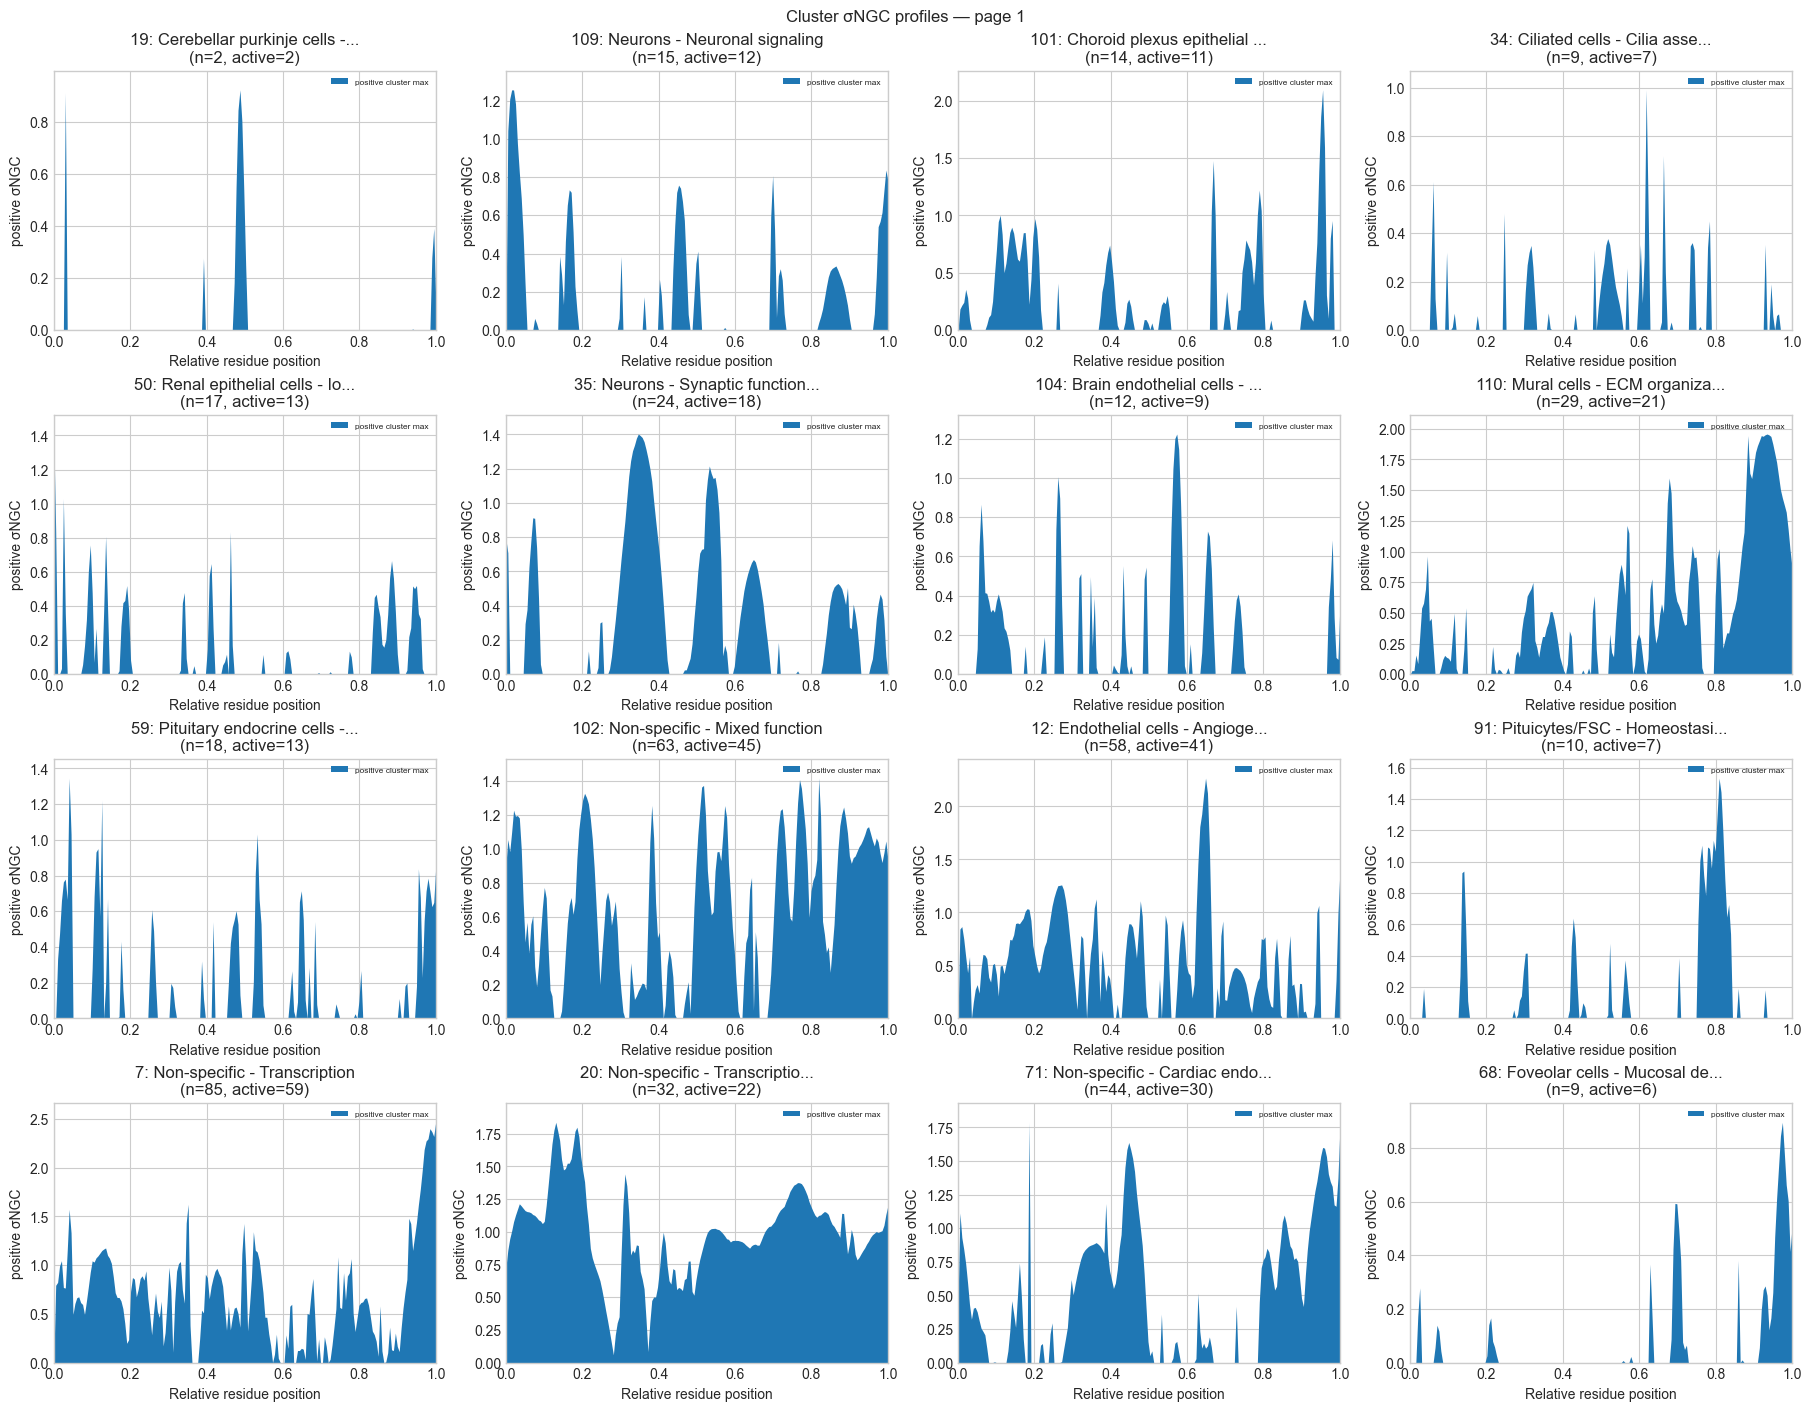

In [18]:
# graph displaying hyperplane distance sigmaNGC histogram over amino acid sequence
# there should be one graph for each unique cluster value in the csv


def positive_sigma(values: np.ndarray, fill_value: float) -> np.ndarray:
    positive = np.isfinite(values) & (values > SIGMA_ACTIVITY_THRESHOLD)
    return np.where(positive, values, fill_value)


def _sigma_ylim(max_sigma: np.ndarray) -> tuple[float, float]:
    positive_values = max_sigma[np.isfinite(max_sigma) & (max_sigma > SIGMA_ACTIVITY_THRESHOLD)]
    hi = float(np.max(positive_values)) if positive_values.size else 0.1
    pad = 0.08 * max(hi, 0.1)
    return (0.0, hi + pad)


def draw_sigma_histogram(ax, group: ClusterGroup) -> None:
    x = np.linspace(0.0, 1.0, PROFILE_GRID)
    stacked = group.stacked_relative_sigma()
    max_sigma = np.nanmax(stacked, axis=0)
    positive_max = positive_sigma(max_sigma, fill_value=0.0)
    n_active = sum(item.statistics.active_positions > 0 for item in group.profiles)

    ax.fill_between(
        x,
        positive_max,
        color="C0",
        linewidth=0,
        zorder=2,
        label="positive cluster max",
    )
    ax.axhline(SIGMA_ACTIVITY_THRESHOLD, color="black", linewidth=0.7, zorder=3)
    ax.set(
        xlim=(0.0, 1.0),
        ylim=_sigma_ylim(max_sigma),
        xlabel="Relative residue position",
        ylabel="positive σNGC",
        title=f"{short_cluster_label(group.name, 34)}\n(n={group.n}, active={n_active})",
    )
    ax.legend(fontsize=6, loc="upper right")


def preview_groups(groups: list[ClusterGroup]) -> list[ClusterGroup]:
    if PLOT_PREVIEW_LIMIT is None:
        return groups
    return groups[: max(0, int(PLOT_PREVIEW_LIMIT))]


def prepare_plot_style_dir(plot_style: str) -> Path:
    save_dir = CLUSTER_PLOT_DIR / plot_style
    save_dir.mkdir(parents=True, exist_ok=True)
    for stale in save_dir.glob("page_*.png"):
        stale.unlink()
    return save_dir


def render_cluster_figure(batch: list[ClusterGroup], draw, suptitle: str, page: int):
    fig, axes = plt.subplots(
        PLOT_GRID_ROWS,
        PLOT_GRID_COLUMNS,
        figsize=(18.0, 14.0),
        layout="constrained",
    )
    flat_axes = axes.ravel()
    for ax, group in zip(flat_axes, batch):
        draw(ax, group)
    for ax in flat_axes[len(batch) :]:
        ax.set_visible(False)
    fig.suptitle(f"{suptitle} — page {page}")
    return fig


def plot_cluster_pages(
    groups: list[ClusterGroup],
    draw,
    *,
    plot_style: str,
    suptitle: str,
    description: str,
) -> None:
    page_size = PLOT_GRID_ROWS * PLOT_GRID_COLUMNS
    display_groups = preview_groups(groups)
    render_groups = groups if SAVE_ALL_CLUSTER_PLOTS else display_groups
    save_dir = prepare_plot_style_dir(plot_style) if SAVE_ALL_CLUSTER_PLOTS else None
    n_pages = (len(render_groups) + page_size - 1) // page_size if render_groups else 0
    print(f"Plotting {len(display_groups)} of {len(groups)} {description}.")
    if save_dir is not None:
        print(f"Saving {len(render_groups)} cluster(s) as {n_pages} 4x4 page(s) to {save_dir}")

    for page, start in enumerate(range(0, len(render_groups), page_size), start=1):
        batch = render_groups[start : start + page_size]
        fig = render_cluster_figure(batch, draw, suptitle, page)
        if save_dir is not None:
            fig.savefig(save_dir / f"page_{page:02d}.png", dpi=SAVE_DPI, bbox_inches="tight")
        if start < len(display_groups):
            plt.show()
        else:
            plt.close(fig)


def plot_sigma_by_cluster(groups: list[ClusterGroup]) -> None:
    plot_cluster_pages(
        groups,
        draw_sigma_histogram,
        plot_style="sigma_ngc",
        suptitle="Cluster σNGC profiles",
        description="cluster σ profiles",
    )


plot_sigma_by_cluster(clusters)

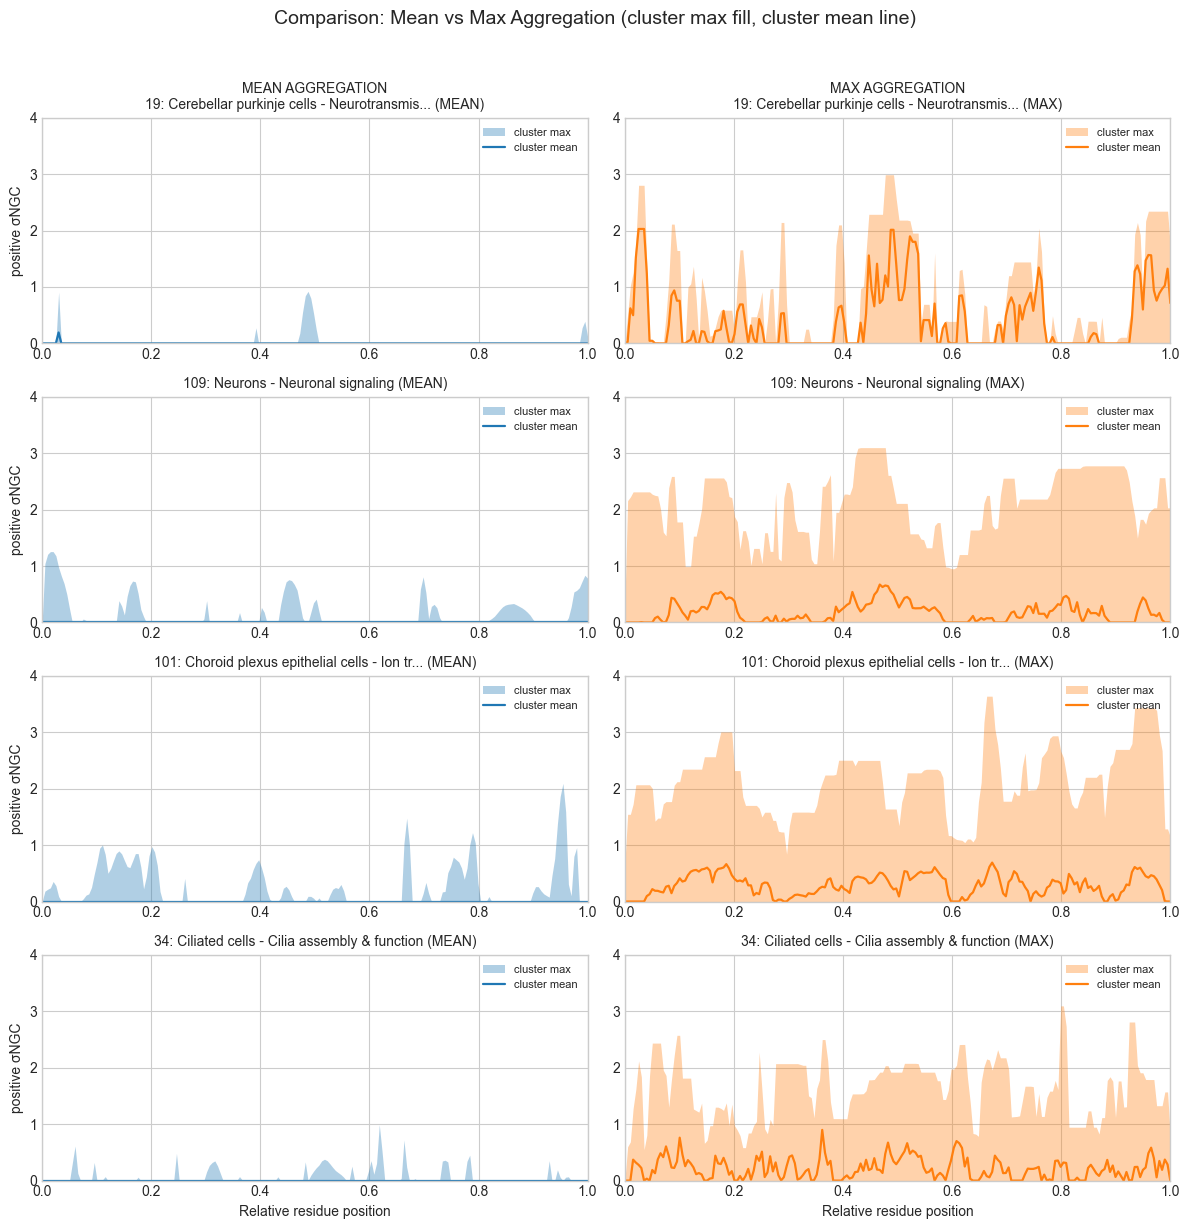

In [19]:
# TEMPORARY CELL: Compare Mean vs Max Aggregation directly
import matplotlib.pyplot as plt
import numpy as np

def compare_mean_max_sigma(groups: list[ClusterGroup], num_clusters: int = 4):
    # Load both profiles directly from the CSV
    df = pd.read_csv(PROFILES_CSV)
    
    # Select the top N clusters
    top_groups = groups[:num_clusters]
    
    fig, axes = plt.subplots(num_clusters, 2, figsize=(12, 3 * num_clusters), squeeze=False)
    fig.suptitle("Comparison: Mean vs Max Aggregation (cluster max fill, cluster mean line)", fontsize=14, y=1.02)
    
    # Find global max across all selected clusters for fixed Y-axis
    global_max = 0.0
    
    for i, group in enumerate(top_groups):
        # Get the original rows for this cluster
        cluster_df = df[df[CLUSTER_COL] == group.name]
        
        for j, mode in enumerate(["mean", "max"]):
            col_name = f"hyperplane_distance_{mode}_profile"
            
            # Parse profiles
            profiles = []
            for _, row in cluster_df.iterrows():
                delimiter = str(row.get(DELIMITER_COL, ";"))
                prof = parse_profile(row[col_name], delimiter)
                # Interpolate to common grid
                prof = interpolate_profile(prof)
                profiles.append(prof)
                
            if not profiles:
                continue
                
            stacked = np.vstack(profiles)
            max_sigma = np.nanmax(stacked, axis=0)
            mean_sigma = np.nanmean(stacked, axis=0)
            positive_max = positive_sigma(max_sigma, fill_value=0.0)
            positive_mean = positive_sigma(mean_sigma, fill_value=0.0)
            
            global_max = max(global_max, float(np.nanmax(positive_max)))
            
            ax = axes[i, j]
            x = np.linspace(0.0, 1.0, PROFILE_GRID)
            
            color = "C0" if mode == "mean" else "C1"
            ax.fill_between(x, positive_max, color=color, linewidth=0, alpha=0.35, label="cluster max")
            ax.plot(x, positive_mean, color=color, linewidth=1.6, label="cluster mean")
            ax.axhline(SIGMA_ACTIVITY_THRESHOLD, color="black", linewidth=0.7)
            ax.legend(fontsize=8, loc="upper right")
            
            title = f"{short_cluster_label(group.name)} ({mode.upper()})"
            if i == 0:
                title = f"{mode.upper()} AGGREGATION\n{title}"
            ax.set_title(title, fontsize=10)
            ax.set_xlim(0.0, 1.0)
            
            if i == num_clusters - 1:
                ax.set_xlabel("Relative residue position")
            if j == 0:
                ax.set_ylabel("positive σNGC")
                
    # Apply fixed Y-axis to all plots so the height difference is obvious
    fixed_ylim = (0.0, global_max * 1.1 if global_max > 0 else 1.0)
    for ax in axes.flat:
        ax.set_ylim(fixed_ylim)
        
    plt.tight_layout()
    plt.show()

# Run the comparison on the top 4 clusters
compare_mean_max_sigma(clusters, num_clusters=4)


Plotting 16 of 16 DNGC distributions.


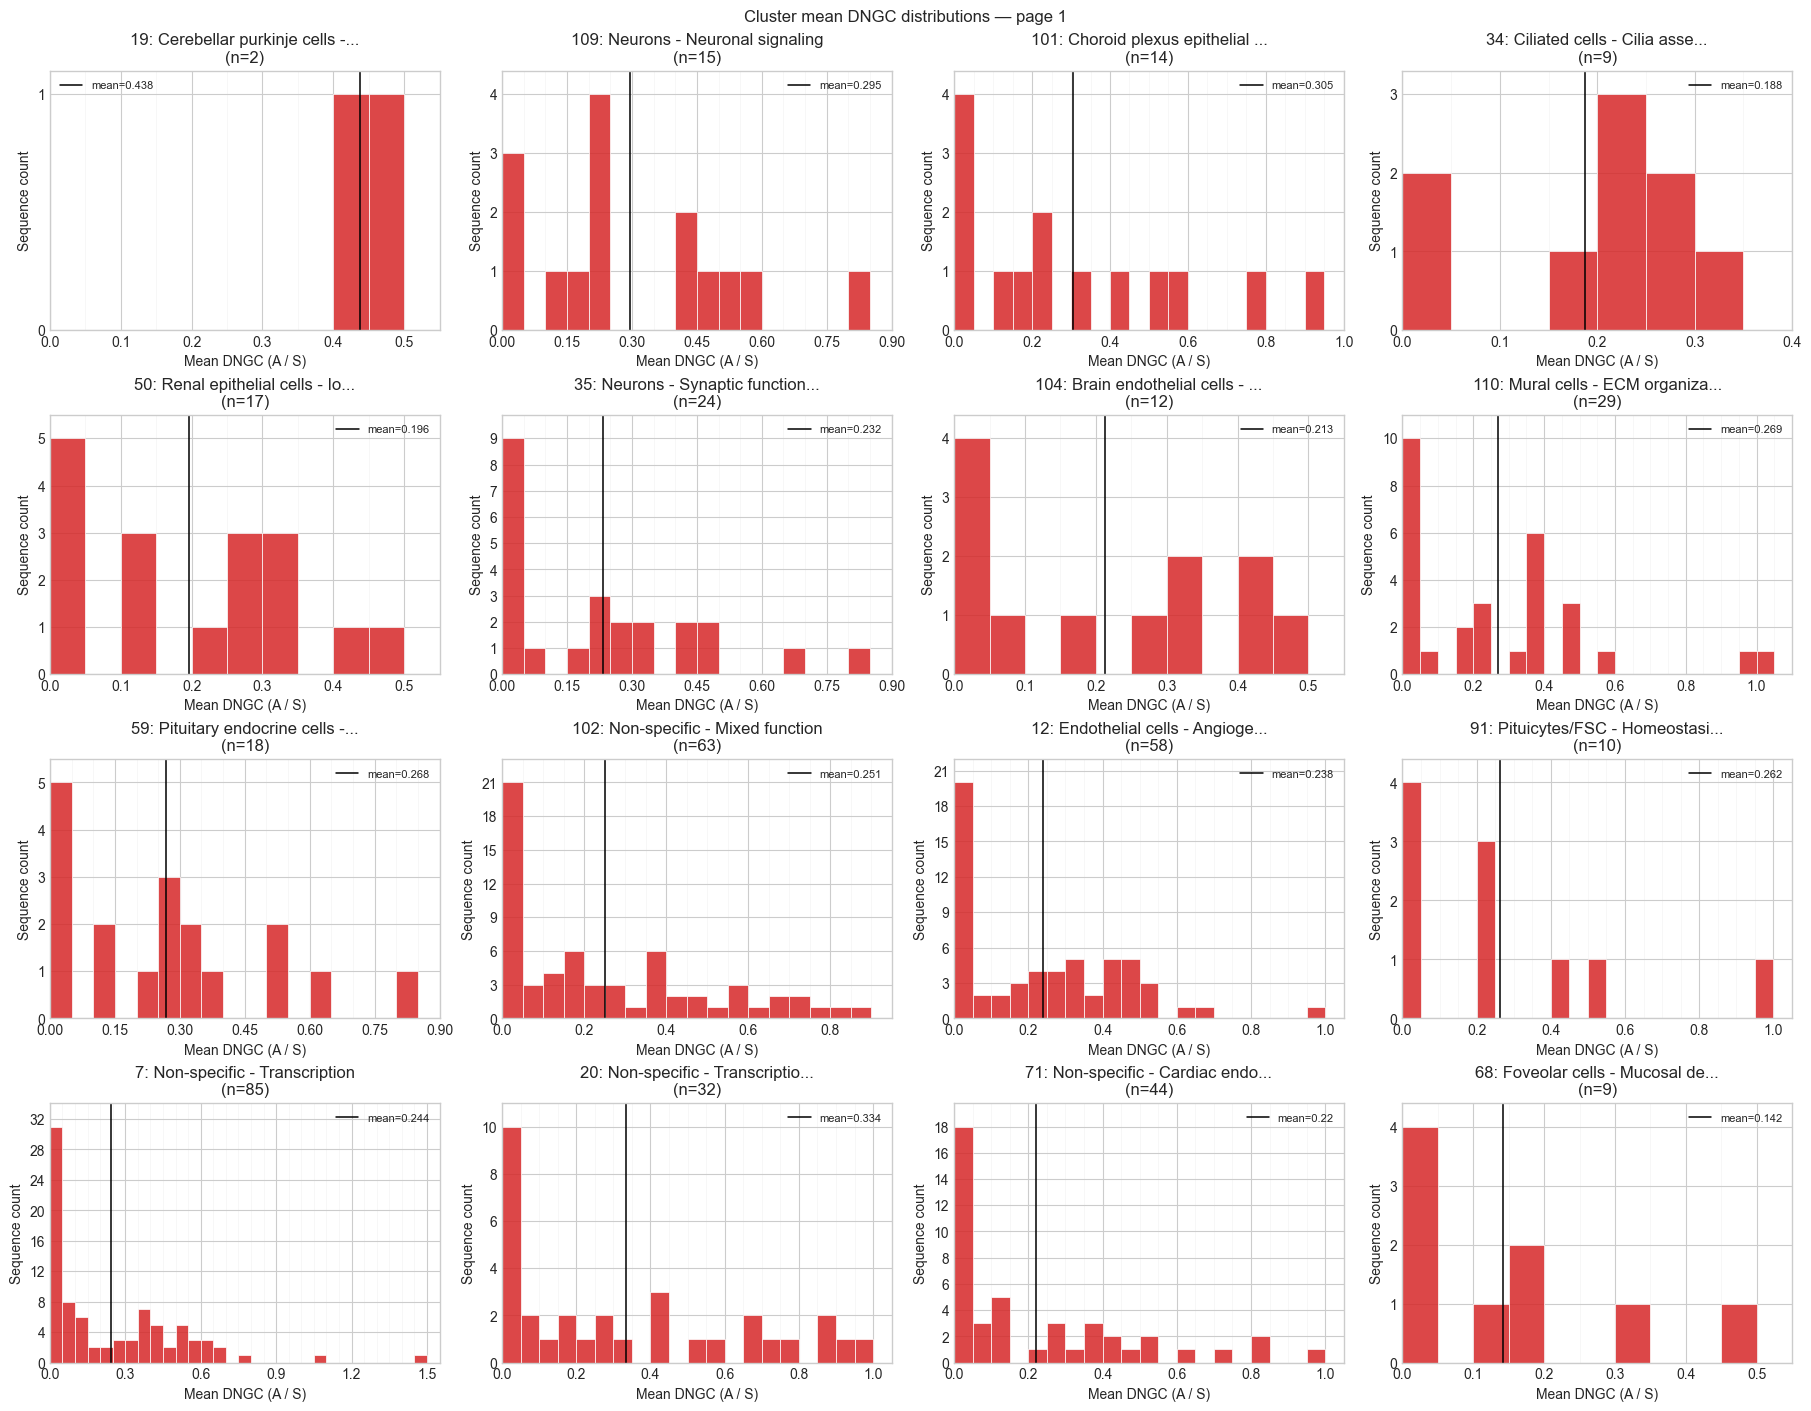

In [20]:
def fixed_width_bins(values: np.ndarray, width: float) -> np.ndarray:
    finite = values[np.isfinite(values)]
    maximum = float(finite.max()) if finite.size else 0.0
    data_upper = max(width, float(np.ceil(maximum / width) * width))
    return np.arange(0.0, data_upper + width * 1.5, width)


def configure_histogram_x_axis(ax, bins: np.ndarray, max_labels: int = 6) -> None:
    bin_width = float(bins[1] - bins[0])
    bin_count = len(bins) - 1
    label_stride = max(1, int(np.ceil(bin_count / max_labels)))
    ax.xaxis.set_major_locator(MultipleLocator(bin_width * label_stride))
    if label_stride > 1:
        ax.xaxis.set_minor_locator(MultipleLocator(bin_width))
        ax.tick_params(axis="x", which="minor", labelbottom=False)
        ax.grid(which="minor", axis="x", linewidth=0.4, alpha=0.25)


def draw_distribution(
    ax,
    values: np.ndarray,
    bins: np.ndarray,
    title: str,
    xlabel: str,
    color: str,
    all_zero_message: str | None = None,
) -> None:
    finite = values[np.isfinite(values)]
    ax.hist(
        finite,
        bins=bins,
        color=color,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.6,
    )
    if finite.size:
        mean = float(np.mean(finite))
        ax.axvline(mean, color="black", linewidth=1.1, label=f"mean={mean:.3g}")
        ax.legend(fontsize=8)
    if all_zero_message and finite.size and np.allclose(finite, 0.0):
        ax.text(
            0.5,
            0.88,
            all_zero_message.format(count=finite.size),
            ha="center",
            transform=ax.transAxes,
            fontsize=8,
        )
    ax.set(
        xlim=(float(bins[0]), float(bins[-1])),
        xlabel=xlabel,
        ylabel="Sequence count",
        title=title,
    )
    ax.margins(y=0.1)
    configure_histogram_x_axis(ax, bins)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))


def cluster_dngc_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.dngc for item in group.profiles],
        dtype=np.float64,
    )


def draw_cluster_dngc_distribution(ax, group: ClusterGroup) -> None:
    values = cluster_dngc_values(group)
    draw_distribution(
        ax,
        values,
        fixed_width_bins(values, DNGC_BIN_WIDTH),
        f"{short_cluster_label(group.name, 34)}\n(n={group.n})",
        "Mean DNGC (A / S)",
        "C3",
        "All {count} sequences have DNGC = 0",
    )


def plot_cluster_dngc_distributions(groups: list[ClusterGroup]) -> None:
    plot_cluster_pages(
        groups,
        draw_cluster_dngc_distribution,
        plot_style="dngc",
        suptitle="Cluster mean DNGC distributions",
        description="DNGC distributions",
    )


plot_cluster_dngc_distributions(clusters)

Plotting 16 of 16 S distributions.


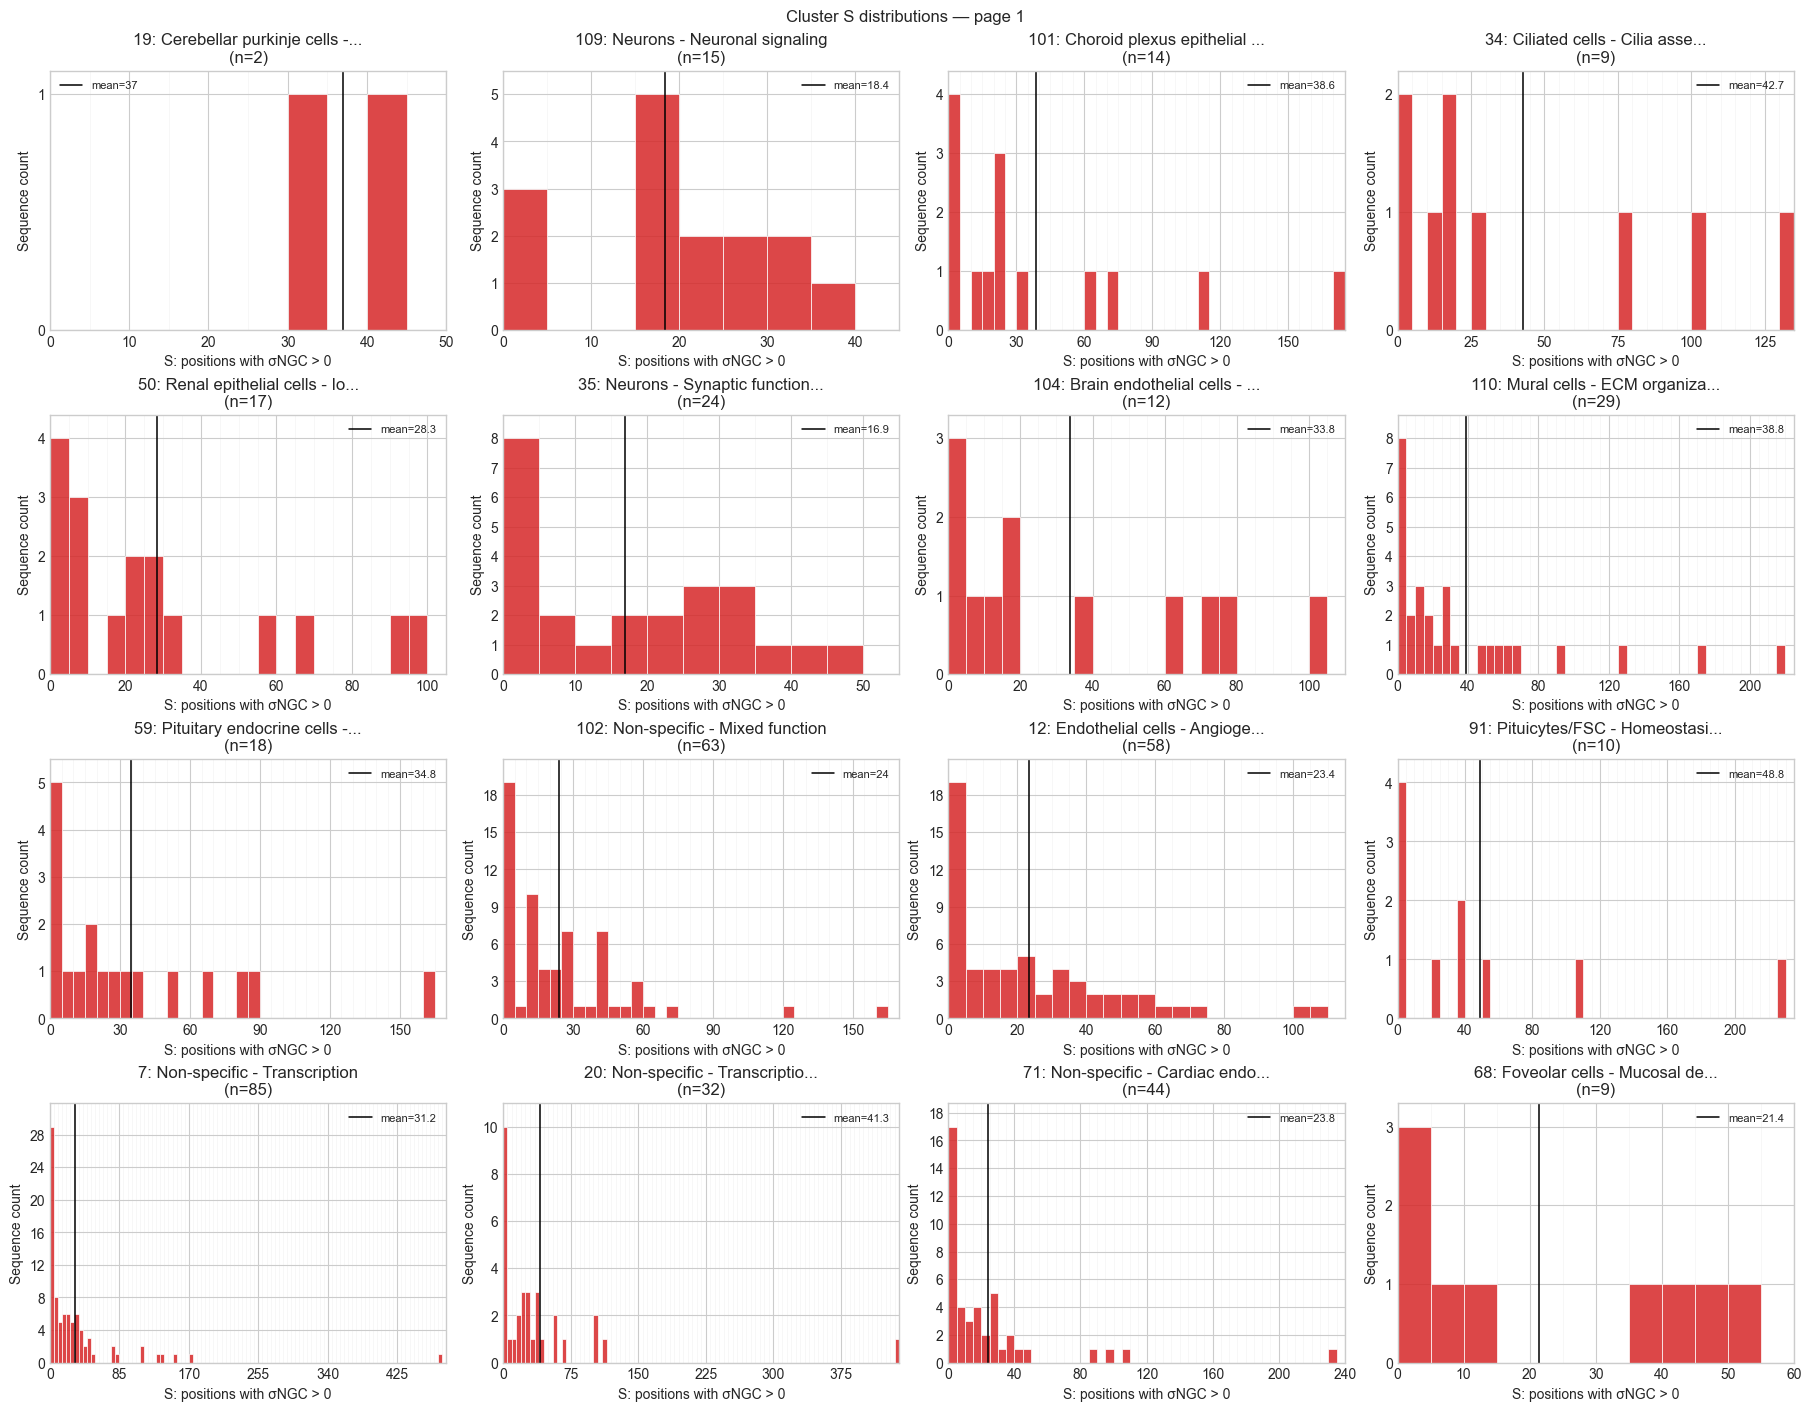

In [21]:
def sequence_s_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.active_positions for item in group.profiles],
        dtype=np.float64,
    )


def draw_cluster_s_distribution(ax, group: ClusterGroup) -> None:
    values = sequence_s_values(group)
    draw_distribution(
        ax,
        values,
        fixed_width_bins(values, S_BIN_WIDTH),
        f"{short_cluster_label(group.name, 34)}\n(n={group.n})",
        "S: positions with σNGC > 0",
        "C3",
        "All {count} sequences have S = 0",
    )


def plot_cluster_s_distributions(groups: list[ClusterGroup]) -> None:
    plot_cluster_pages(
        groups,
        draw_cluster_s_distribution,
        plot_style="s",
        suptitle="Cluster S distributions",
        description="S distributions",
    )


plot_cluster_s_distributions(clusters)

Plotting 16 of 16 A distributions.


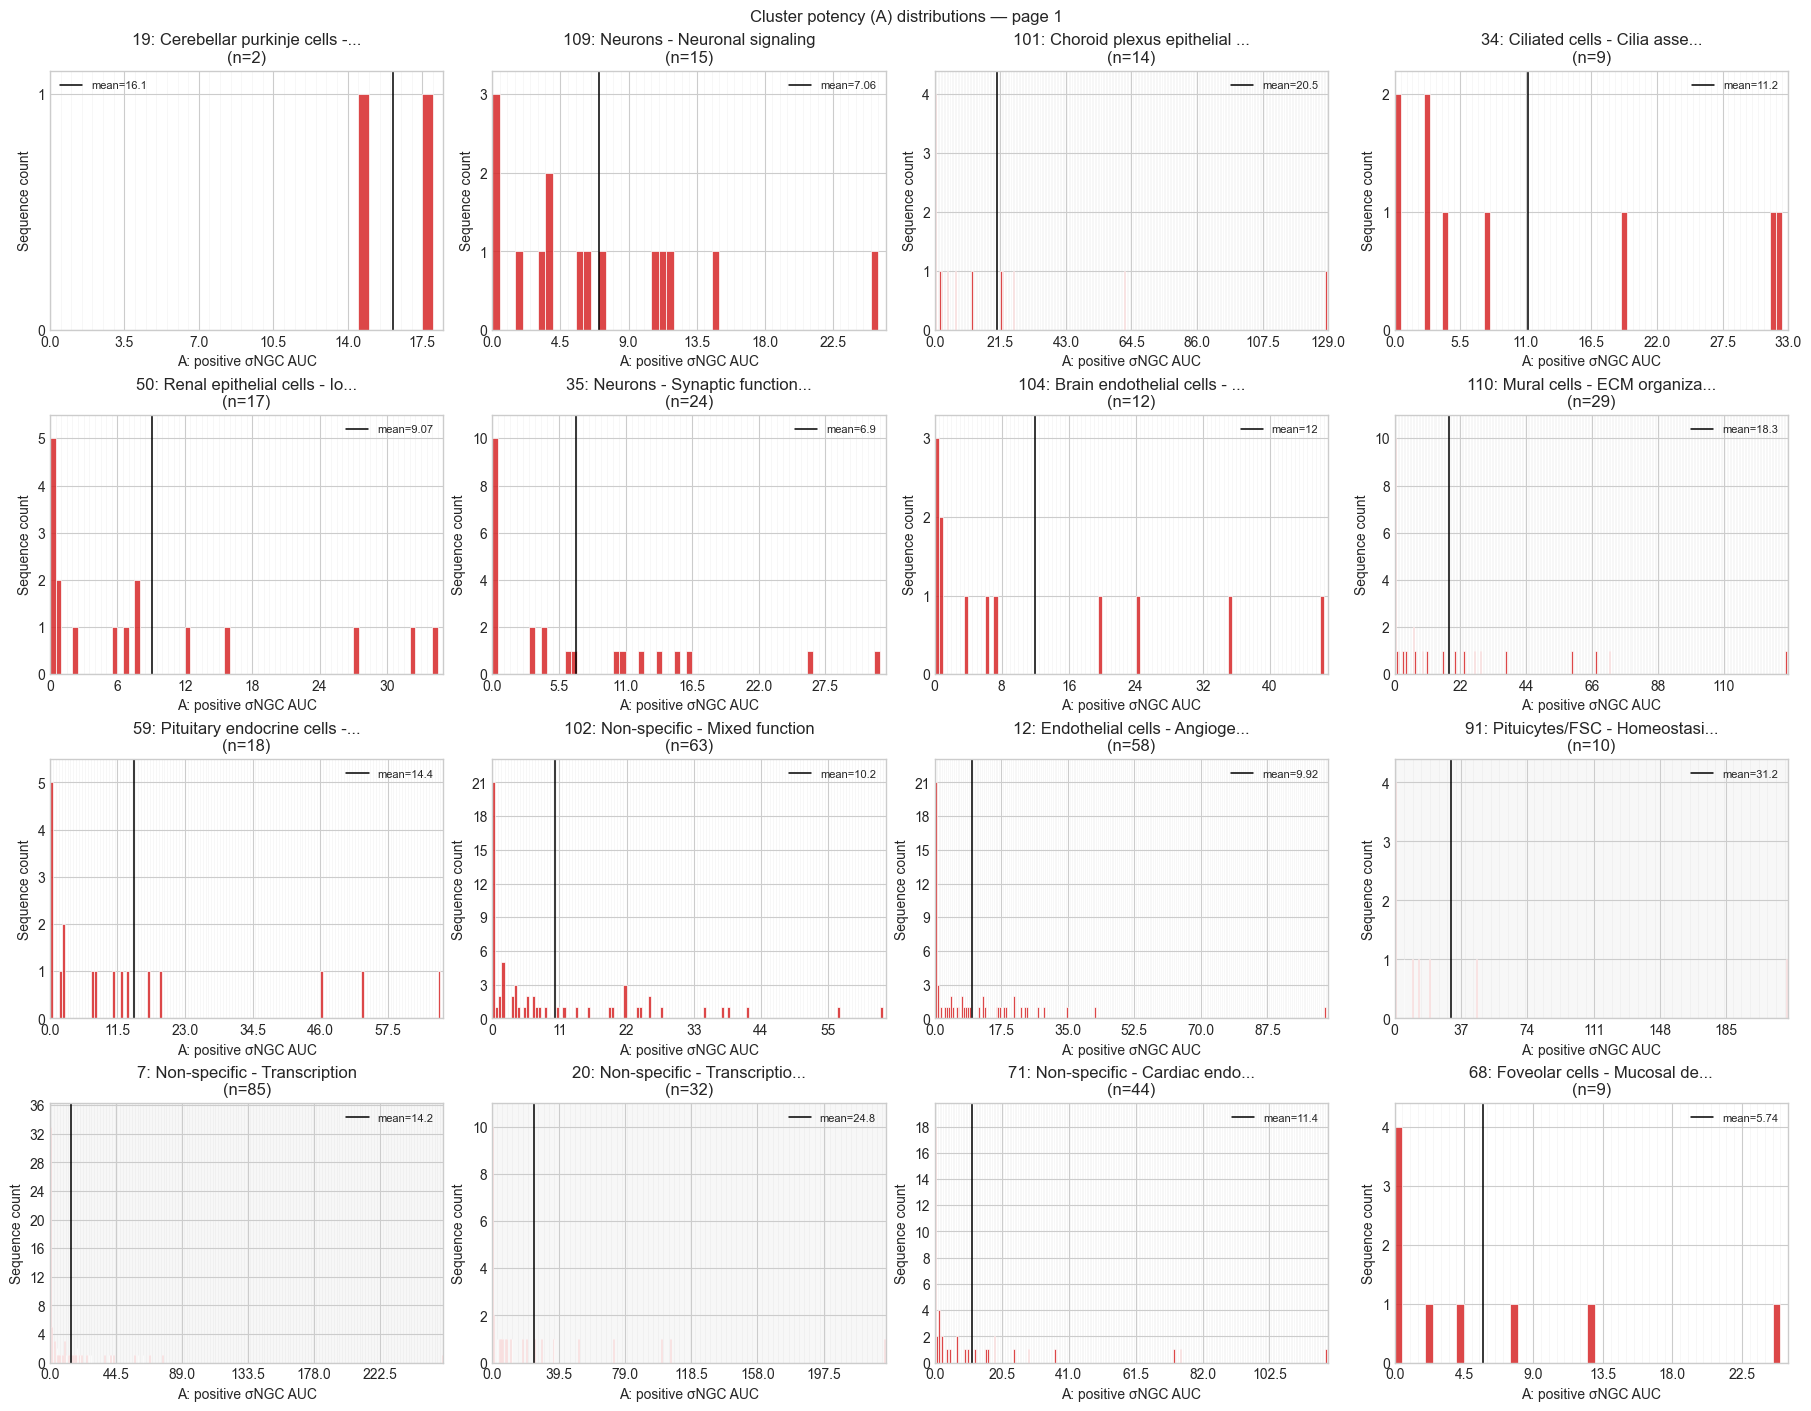

In [22]:
def sequence_a_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.potency_auc for item in group.profiles],
        dtype=np.float64,
    )


def draw_cluster_a_distribution(ax, group: ClusterGroup) -> None:
    values = sequence_a_values(group)
    draw_distribution(
        ax,
        values,
        fixed_width_bins(values, AUC_BIN_WIDTH),
        f"{short_cluster_label(group.name, 34)}\n(n={group.n})",
        "A: positive σNGC AUC",
        "C3",
        "All {count} sequences have A = 0",
    )


def plot_cluster_a_distributions(groups: list[ClusterGroup]) -> None:
    plot_cluster_pages(
        groups,
        draw_cluster_a_distribution,
        plot_style="a",
        suptitle="Cluster potency (A) distributions",
        description="A distributions",
    )


plot_cluster_a_distributions(clusters)

Plotting 16 of 16 F distributions.


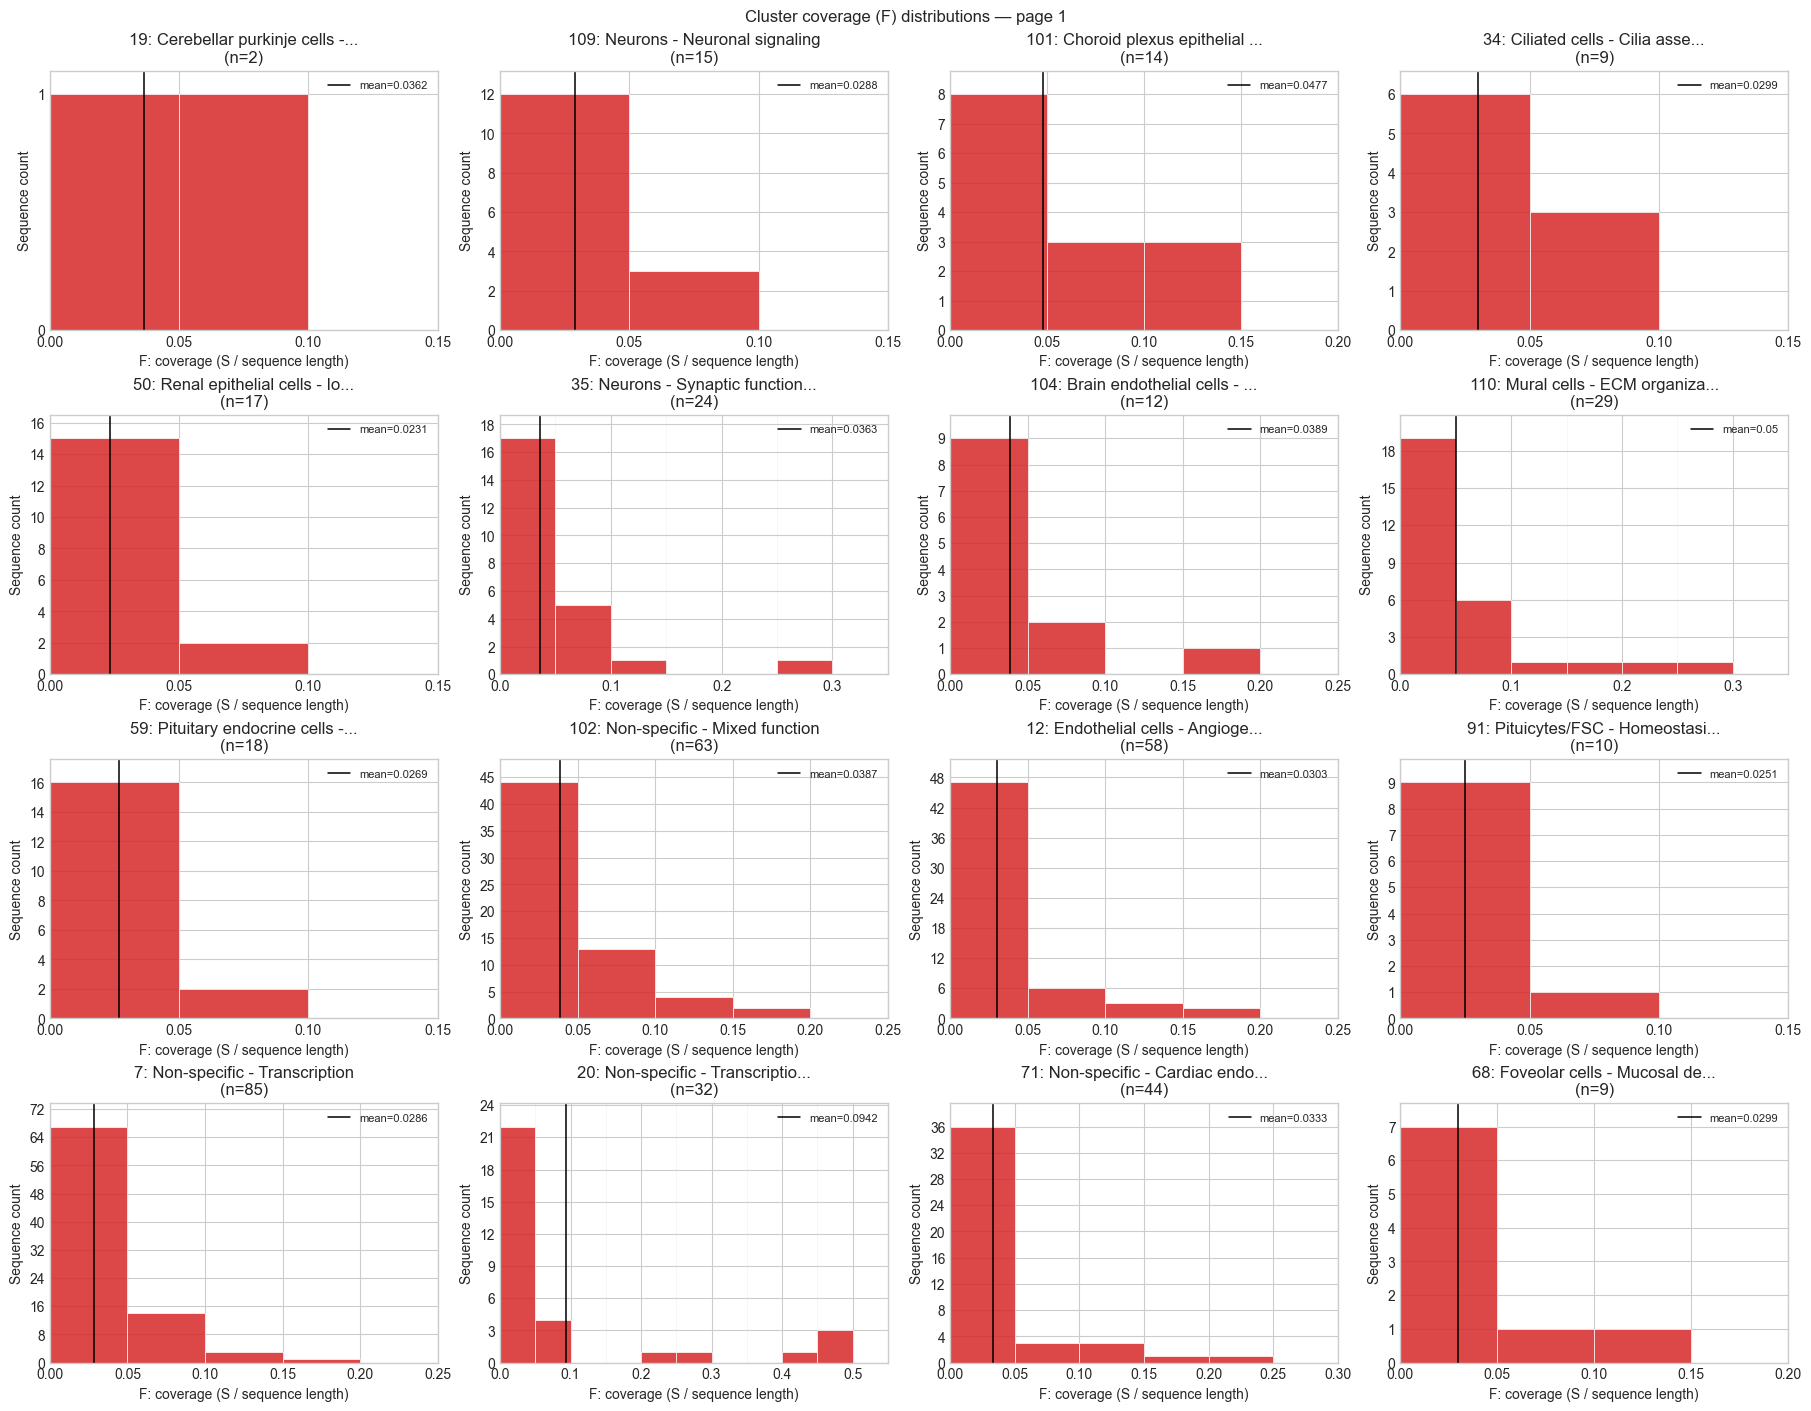

In [23]:
def sequence_f_values(group: ClusterGroup) -> np.ndarray:
    return np.asarray(
        [item.statistics.coverage for item in group.profiles],
        dtype=np.float64,
    )


def draw_cluster_f_distribution(ax, group: ClusterGroup) -> None:
    values = sequence_f_values(group)
    draw_distribution(
        ax,
        values,
        fixed_width_bins(values, F_BIN_WIDTH),
        f"{short_cluster_label(group.name, 34)}\n(n={group.n})",
        "F: coverage (S / sequence length)",
        "C3",
        "All {count} sequences have F = 0",
    )


def plot_cluster_f_distributions(groups: list[ClusterGroup]) -> None:
    plot_cluster_pages(
        groups,
        draw_cluster_f_distribution,
        plot_style="f",
        suptitle="Cluster coverage (F) distributions",
        description="F distributions",
    )


plot_cluster_f_distributions(clusters)